<a href="https://colab.research.google.com/github/mducdaf2/jetracer-car/blob/dev/notebooks/TrafficSignModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!7z x datasets.zip


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 364196 bytes (356 KiB)

Extracting archive: datasets.zip
--
Path = datasets.zip
Type = zip
Physical Size = 364196

  0%    Everything is Ok

Folders: 5
Files: 8
Size:       365251
Compressed: 364196


In [29]:
import os
from pathlib import Path
import json
import json
from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [15]:
data_dir = Path("sign_dataset")
list(data_dir.iterdir())

[PosixPath('sign_dataset/images'),
 PosixPath('sign_dataset/labels'),
 PosixPath('sign_dataset/classes.json')]

In [16]:
list(Path(data_dir / "images").iterdir())

[PosixPath('sign_dataset/images/img_1786604713916.jpg'),
 PosixPath('sign_dataset/images/img_1786604721780.jpg')]

In [19]:
list(Path(data_dir / "labels").iterdir())

[PosixPath('sign_dataset/labels/img_1786604713916.json'),
 PosixPath('sign_dataset/labels/img_1786604721780.json')]

In [24]:
with open(data_dir / "labels" / "img_1786604713916.json") as f:
    data = json.load(f)
data

{'image': 'img_1786604713916.jpg',
 'width': 640,
 'height': 480,
 'shapes': [{'class_id': 0,
   'label': 'Biển báo cấm',
   'bbox_pixel': {'x': 134, 'y': 184, 'w': 80, 'h': 103},
   'bbox_yolo': [0.271875, 0.490625, 0.125, 0.214583]},
  {'class_id': 0,
   'label': 'Biển báo cấm',
   'bbox_pixel': {'x': 275, 'y': 231, 'w': 55, 'h': 87},
   'bbox_yolo': [0.472656, 0.571875, 0.085938, 0.18125]},
  {'class_id': 2,
   'label': 'Biển rẽ trái',
   'bbox_pixel': {'x': 348, 'y': 146, 'w': 62, 'h': 82},
   'bbox_yolo': [0.592187, 0.389583, 0.096875, 0.170833]}]}

In [27]:
class SignDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.images_dir = self.data_dir / "images"
        self.labels_dir = self.data_dir / "labels"
        self.transform = transform

        # Lấy danh sách tất cả các file JSON nhãn
        self.label_files = sorted(list(self.labels_dir.glob("*.json")))

    def __len__(self):
        return len(self.label_files)

    def __getitem__(self, idx):
        # 1. Đọc file label JSON
        json_path = self.label_files[idx]
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # 2. Đọc file ảnh tương ứng
        img_name = data['image']
        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")

        # 3. Trích xuất bounding boxes và class labels
        boxes = []
        labels = []

        for shape in data.get('shapes', []):
            labels.append(shape['class_id'])

            # Sử dụng bbox_yolo dạng [x_center, y_center, width, height] (đã chuẩn hóa 0-1)
            # Hoặc bbox_pixel dạng [x, y, w, h] tùy thuộc vào bài toán/mô hình của bạn
            boxes.append(shape['bbox_yolo'])

        # Chuyển đổi sang PyTorch Tensor
        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        # 4. Áp dụng Augmentation/Transform nếu có
        if self.transform:
            image = self.transform(image)

        # Trả về dạng dictionary phù hợp cho bài toán Object Detection (như Faster R-CNN, YOLO, DETR,...)
        target = {
            'boxes': boxes,
            'labels': labels,
            'image_id': torch.tensor([idx])
        }

        return image, target


# Hàm collate_fn cần thiết vì số lượng bboxes trong mỗi ảnh khác nhau
def collate_fn(batch):
    return tuple(zip(*batch))

In [28]:
# Ví dụ về biến đổi ảnh (Transform)
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Khởi tạo Dataset
dataset = SignDataset(data_dir="sign_dataset", transform=transform)

# Khởi tạo DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn # Bắt buộc phải có collate_fn cho bài toán Object Detection
)

# Chạy thử vòng lặp kiểm tra
for images, targets in dataloader:
    print(f"Số lượng ảnh trong batch: {len(images)}")
    print(f"Kích thước ảnh đầu tiên: {images[0].shape}")
    print(f"Nhãn của ảnh đầu tiên: {targets[0]['labels']}")
    print(f"BBox của ảnh đầu tiên:\n{targets[0]['boxes']}")
    break

Số lượng ảnh trong batch: 2
Kích thước ảnh đầu tiên: torch.Size([3, 480, 640])
Nhãn của ảnh đầu tiên: tensor([0, 0, 2])
BBox của ảnh đầu tiên:
tensor([[0.2719, 0.4906, 0.1250, 0.2146],
        [0.4727, 0.5719, 0.0859, 0.1813],
        [0.5922, 0.3896, 0.0969, 0.1708]])


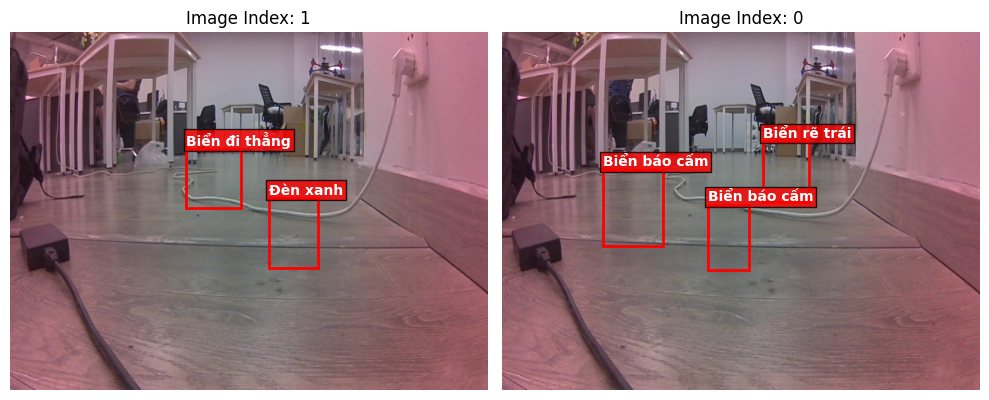

In [30]:
def load_class_names(json_path):
    with open(json_path, 'r', encoding='utf-8') as f:
        raw_classes = json.load(f)
    # Tự động ép kiểu key từ string sang integer để khớp với label_id của PyTorch
    return {int(k): v for k, v in raw_classes.items()}

# 2. Đọc file classes.json
classes_file = Path("sign_dataset/classes.json")
CLASS_NAMES = load_class_names(classes_file)

def visualize_batch(dataloader, class_names=CLASS_NAMES):
    # Lấy batch đầu tiên
    images, targets = next(iter(dataloader))

    batch_size = len(images)
    cols = min(4, batch_size)
    rows = (batch_size + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    if batch_size == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for idx in range(batch_size):
        ax = axes[idx]

        # 1. Chuyển PyTorch Tensor ảnh về dạng NumPy để vẽ (C, H, W -> H, W, C)
        img = images[idx].permute(1, 2, 0).cpu().numpy()
        # Clip giá trị về khoảng [0, 1] phòng trường hợp ảnh chưa normalize chuẩn
        img = np.clip(img, 0, 1)

        height, width, _ = img.shape
        ax.imshow(img)

        boxes = targets[idx]['boxes']
        labels = targets[idx]['labels']

        # 2. Vẽ từng bounding box
        for box, label in zip(boxes, labels):
            box = box.numpy()
            label_id = label.item()
            label_name = class_names.get(label_id, f"Class {label_id}")

            # Giải mã bbox_yolo dạng [x_center, y_center, w, h] (đã chuẩn hóa 0-1) sang pixel
            x_center, y_center, w, h = box
            xmin = (x_center - w / 2) * width
            ymin = (y_center - h / 2) * height
            box_w = w * width
            box_h = h * height

            # Tạo hình chữ nhật cho BBox
            rect = patches.Rectangle(
                (xmin, ymin), box_w, box_h,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

            # Vẽ nhãn chữ lên trên bbox
            ax.text(
                xmin, max(ymin - 5, 0), label_name,
                color='white', fontsize=10, weight='bold',
                bbox=dict(boxstyle='square,pad=0.2', facecolor='red', alpha=0.8)
            )

        ax.set_title(f"Image Index: {targets[idx]['image_id'].item()}")
        ax.axis('off')

    # Ẩn các ô thừa nếu batch_size không lấp đầy grid
    for idx in range(batch_size, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# --- GỌI HÀM HIỂN THỊ ---
visualize_batch(dataloader)